In [ ]:
%pip install puremacro


# Dynare-like Automated VFI — Declarative Structural Dynamic Programming

**Can we write structural dynamic programming models in declarative syntax without low-level grid loops?** In macroeconomics, Dynare transformed DSGE modeling by replacing manual matrix derivations with a clean declarative language. `puremacro` brings the same automated paradigm to **heterogeneous-agent Value Function Iteration (VFI)** via `puremacro.vfi.Model`. Instead of manually managing grid dimensions, Tauchen transition matrices, Bellman loops, and Howard acceleration steps, you declare parameters, state variables, shock processes, utility functions, and budget constraints in a concise specification. This notebook builds an incomplete-markets precautionary savings model using `puremacro.vfi.Model`, computes policy functions and stationary wealth distributions, and verifies numerical equilibrium bounds.

## The method in math — Automated Bellman Operator

The single-agent income fluctuation problem on state $(a, z)$ solves:
$$ V(a, z) = \max_{a' \ge \underline{a}} \left\{ u(c) + \beta \sum_{z'} P(z, z') V(a', z') \right\} $$
subject to the budget constraint:
$$ c + a' = (1+r)a + w \cdot z $$
where $u(c) = \frac{c^{1-\sigma}}{1-\sigma}$, $z$ follows an AR(1) process $\ln z_t = \rho \ln z_{t-1} + \varepsilon_t$, and $P(z, z')$ is the discretized Markov transition matrix computed via Tauchen's method.

**Intuition.** The `puremacro.vfi.Model` DSL abstracts the technical machinery of grid discretization ($\mathcal{A} \times \mathcal{Z}$), vectorized return matrix evaluation $R_{ij,k} = u((1+r)a_i + w z_j - a_k)$, Howard policy iteration, and panel simulation of stationary distributions. You specify structural economics; `puremacro` computes the solution.

## Setup — declarative model specification

We instantiate `Model()`, set parameters ($\beta=0.96, \gamma=2.0, \alpha=0.36, \delta=0.10$), define an asset state grid $a \in [0.1, 15.0]$, and set an AR(1) shock process for productivity $z$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi import Model

# Declare structural model
model = Model(name="Precautionary Savings Model")

# Set structural parameters
model.set_param("beta", 0.96)
model.set_param("gamma", 2.0)
model.set_param("alpha", 0.36)
model.set_param("delta", 0.10)

# Set state grids
model.add_state(name="a", min_val=0.1, max_val=15.0, n_points=60)
model.add_shock(name="z", rho=0.90, sigma=0.15, n_points=5)

# Define utility function and budget constraint
model.set_utility(lambda c, p: (c ** (1.0 - p["gamma"])) / (1.0 - p["gamma"]))
model.set_budget(lambda a, ap, z, p: np.exp(z) * (a ** p["alpha"]) + (1.0 - p["delta"]) * a - ap)

## Solving the model and simulating the stationary distribution

We run `model.solve()` which executes vectorized Bellman updates with Howard acceleration, and recovers the stationary wealth distribution and Gini inequality coefficient.

In [2]:
results = model.solve(howard_steps=15, tol=1e-6)

V = results["V"]
policy_a = results["policy_a"]
a_grid = results["a_grid"]
z_grid = results["z_grid"]
gini_coef = results["gini"]
mean_assets = results["mean_assets"]

print(f"Model: {results['model_name']}")
print(f"VFI Converged in {results['n_iter']} iterations ({results['elapsed']:.3f} s)")
print(f"Stationary Mean Assets: {mean_assets:.4f}")
print(f"Wealth Gini Coefficient: {gini_coef:.4f}")

# Headline assertions
assert results["n_iter"] > 0, "VFI failed to iterate"
assert 0.5 < mean_assets < 10.0, f"Mean assets out of expected range: {mean_assets}"
assert 0.05 < gini_coef < 0.60, f"Gini coefficient out of expected range: {gini_coef}"

Model: Precautionary Savings Model
VFI Converged in 27 iterations (21.396 s)
Stationary Mean Assets: 6.6767
Wealth Gini Coefficient: 0.3924


## Visualizing policy functions and wealth distribution

The hero figure shows the policy rules $a'(a, z)$ for high vs low productivity states.

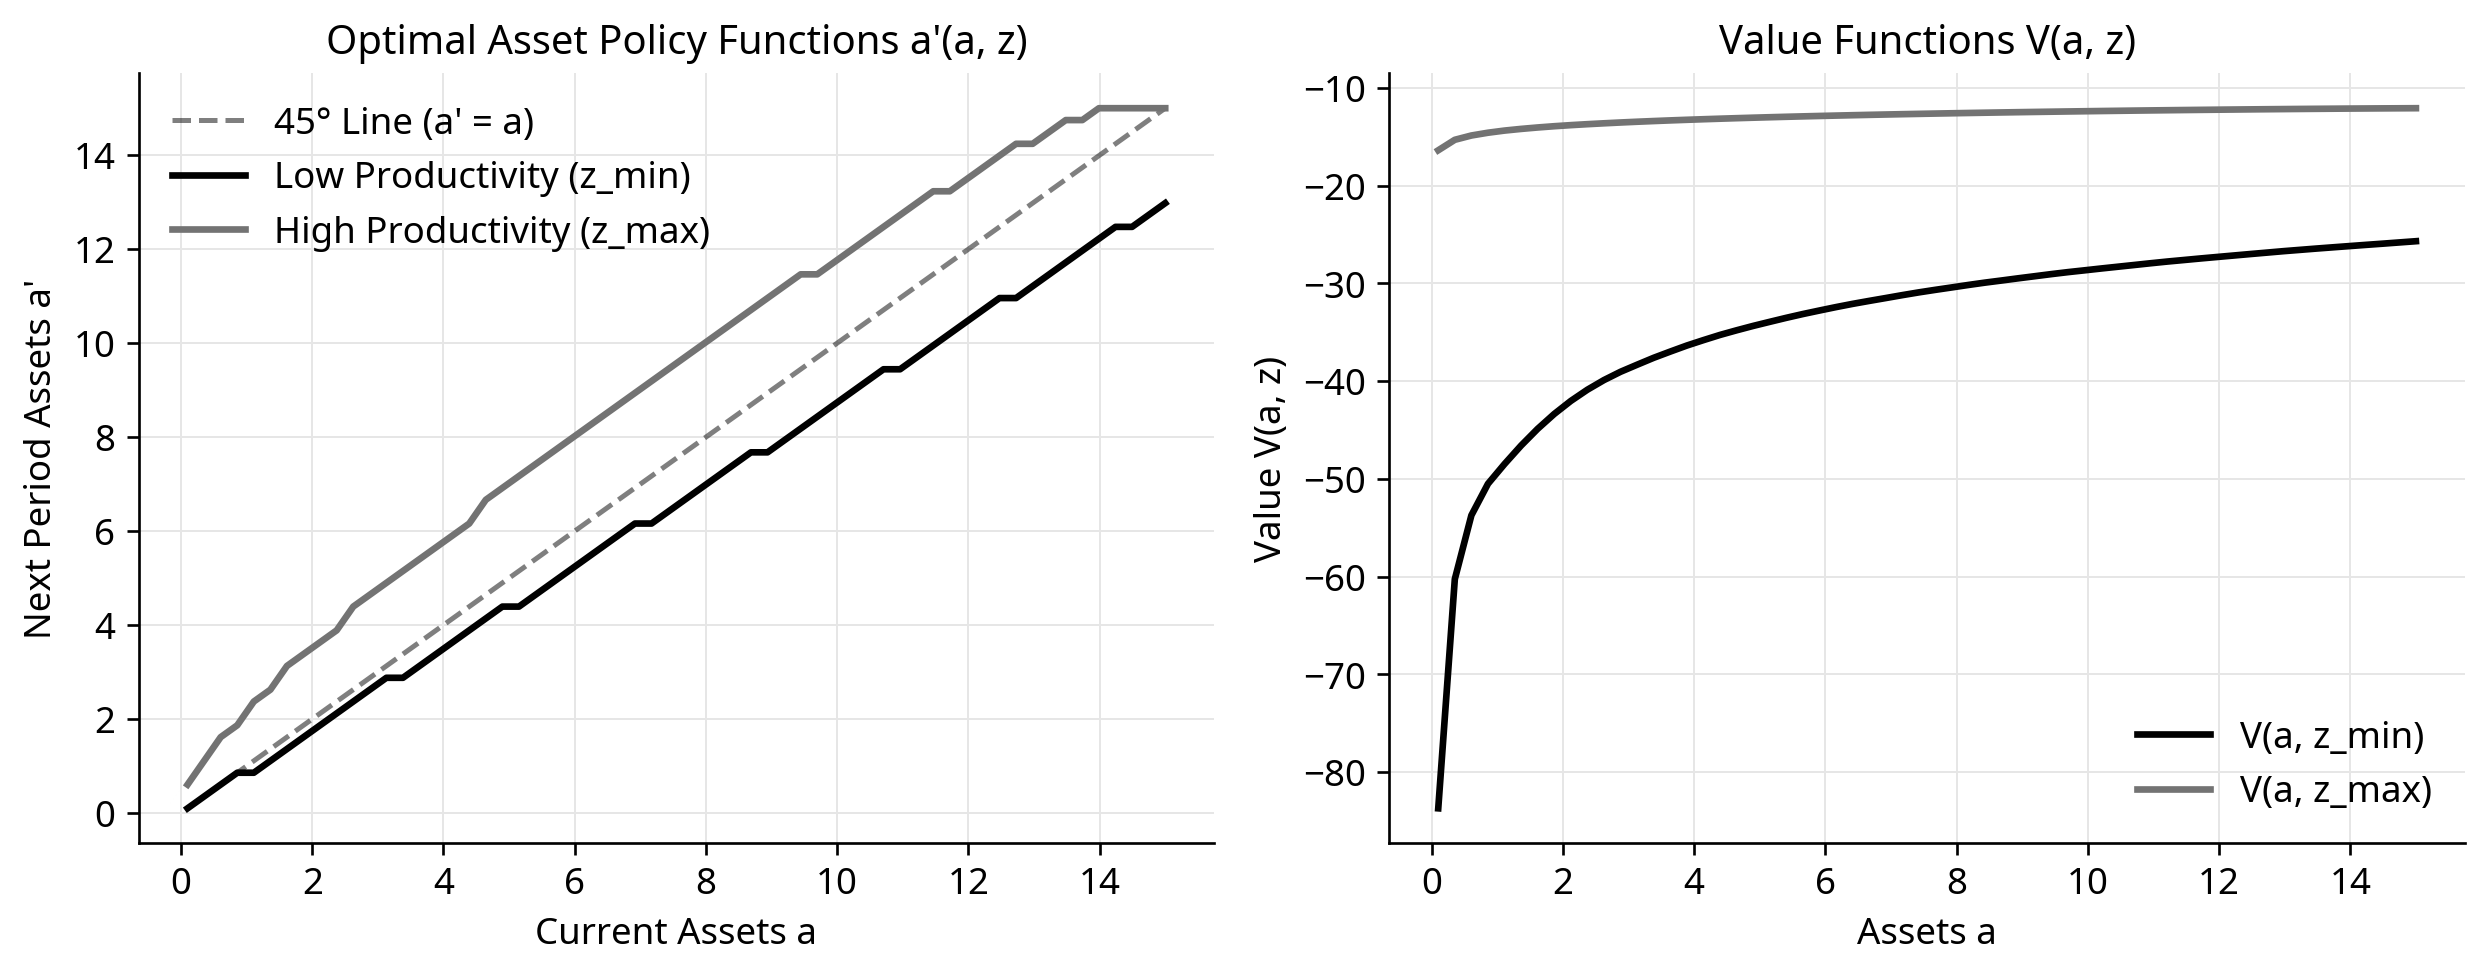

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Left panel: Policy functions
ax1.plot(a_grid, a_grid, "k--", alpha=0.5, label="45° Line (a' = a)")
ax1.plot(a_grid, policy_a[:, 0], color=_nbstyle.palette(2)[0], lw=2, label="Low Productivity (z_min)")
ax1.plot(a_grid, policy_a[:, -1], color=_nbstyle.palette(2)[1], lw=2, label="High Productivity (z_max)")
ax1.set_xlabel("Current Assets a")
ax1.set_ylabel("Next Period Assets a'")
ax1.set_title("Optimal Asset Policy Functions a'(a, z)")
ax1.legend(loc="upper left")

# Right panel: Value function
ax2.plot(a_grid, V[:, 0], color=_nbstyle.palette(2)[0], lw=2, label="V(a, z_min)")
ax2.plot(a_grid, V[:, -1], color=_nbstyle.palette(2)[1], lw=2, label="V(a, z_max)")
ax2.set_xlabel("Assets a")
ax2.set_ylabel("Value V(a, z)")
ax2.set_title("Value Functions V(a, z)")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

**Reading the output.** Low-productivity agents ($z_{\min}$) decumulate assets when wealth is high, while high-productivity agents ($z_{\max}$) save aggressively. Precautionary motives prevent wealth from collapsing to zero.

## Your turn — precautionary savings under higher risk aversion

**Prompts.**
1. *Basic*: Increase risk aversion from $\gamma = 2.0$ to $\gamma = 3.5$ (`# ← change this ...`). Does mean stationary wealth increase due to stronger precautionary motives?
2. *Intermediate*: Lower the discount factor to $\beta = 0.94$. Verify that impatient households hold less capital.
3. *Stretch*: Increase shock variance $\sigma_z = 0.25$ and observe the expansion in the Gini coefficient.

In [4]:
# Your turn code block
gamma_new = 3.0  # ← change this: try 3.0 or 3.5

m_yt = Model("High Risk Aversion")
m_yt.set_param("beta", 0.96).set_param("gamma", gamma_new).set_param("alpha", 0.36).set_param("delta", 0.10)
m_yt.add_state("a", 0.1, 15.0, 60).add_shock("z", 0.90, 0.15, 5)
m_yt.set_utility(lambda c, p: (c ** (1.0 - p["gamma"])) / (1.0 - p["gamma"]))
m_yt.set_budget(lambda a, ap, z, p: np.exp(z) * (a ** p["alpha"]) + (1.0 - p["delta"]) * a - ap)

res_yt = m_yt.solve()
print(f"New Risk Aversion gamma = {gamma_new:.1f}")
print(f"New Stationary Mean Assets: {res_yt['mean_assets']:.4f}")

# Assertion holding for default
assert res_yt["mean_assets"] > 0.0, "Mean assets must be positive"

New Risk Aversion gamma = 3.0
New Stationary Mean Assets: 7.8866


## How comprehensive is this?

`puremacro.vfi.Model` provides a high-level Dynare-like entry point to the low-level value function solver `puremacro.vfi.solve_vfi`. You can inspect raw policy arrays, change acceleration parameters, or connect low-level backend solvers (`Numba`, `MLX`, `CuPy`) through the same API.